In [1]:
import pandas as pd
import numpy as np
from skimpy import clean_columns
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from datetime import datetime
import scipy.stats as stats
from datetime import timedelta
from collections import Counter


/Users/chloecho/anaconda3/envs/cornell_dev/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
residue_data = pd.read_csv('scm_pesticide_residue_2025.csv')
residue_data = clean_columns(residue_data)
residue_data['date_of_collection'] = pd.to_datetime(residue_data['date_of_collection'])
residue_data

/var/folders/vt/gz9c8wh17772k93xq1vtnl0c0000gn/T/ipykernel_84686/3054100503.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  residue_data['date_of_collection'] = pd.to_datetime(residue_data['date_of_collection'])


,raw_file_name,batch_id,sample_id_1,sample_#,site,date_of_collection,pesticide_treatment,weight_g,acephate,dinotefuran,...,s_indoxacarb,trifloxystrobin,piperonyl_butoxide,tetramethrin,fluazinam,pyriproxyfen,pendimethalin,chlorpyrifos,e_fenpyroximate,avermectin_b_1a
0,2026-03-20_P136_SP_022,"Soil, P136-RA1",1,RA1,CHO_GEN,2025-06-06,Neonicotinoid,10.33,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,n.d.,4.50,n.d.,n.d.,n.d.
1,2026-03-20_P136_SP_023,"Soil, P136-RA2",2,RA2,CHO_GEN,2025-06-06,Fungicide,10.26,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,n.d.,4.80,n.d.,n.d.,n.d.
2,2026-03-20_P136_SP_024,"Soil, P136-RA3",3,RA3,CHO_GEN,2025-11-03,Neonicotinoid,10.19,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,n.d.,4.92,n.d.,n.d.,n.d.
3,2026-03-20_P136_SP_025,"Soil, P136-RA4",4,RA4,CHO_GEN,2025-11-03,Fungicide,10.26,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,n.d.,2.42,n.d.,n.d.,n.d.
4,2026-03-20_P136_SP_026,"Soil, P136-RA5",5,RA5,DEG_DIE,2025-06-12,Neonicotinoid,10.23,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,n.d.,3.51,n.d.,n.d.,n.d.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2026-03-20_P136_SP_092,"Soil, P136-RA68",68,RA68,STA_WIL,2025-11-03,Fungicide,10.32,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,n.d.,<LOQ,n.d.,n.d.,n.d.
68,2026-03-20_P136_SP_093,"Soil, P136-RA69",69,RA69,STA_WOO,2025-05-29,Neonicotinoid,10.15,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,n.d.,3.81,n.d.,n.d.,n.d.
69,2026-03-20_P136_SP_094,"Soil, P136-RA70",70,RA70,STA_WOO,2025-05-29,Fungicide,10.27,n.d.,n.d.,...,2.92,1.87,n.d.,n.d.,n.d.,0.33,23.50,n.d.,n.d.,<LOQ
70,2026-03-20_P136_SP_095,"Soil, P136-RA71",71,RA71,STA_WOO,2025-11-26,Neonicotinoid,10.19,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,n.d.,4.28,n.d.,n.d.,n.d.


In [7]:
residue_data['sample_period'] = np.where(residue_data['date_of_collection'] < '2025-07-15', 'Planting', 'Harvest')


In [8]:
residue_data

,raw_file_name,batch_id,sample_id_1,sample_#,site,date_of_collection,pesticide_treatment,weight_g,acephate,dinotefuran,...,trifloxystrobin,piperonyl_butoxide,tetramethrin,fluazinam,pyriproxyfen,pendimethalin,chlorpyrifos,e_fenpyroximate,avermectin_b_1a,sample_period
0,2026-03-20_P136_SP_022,"Soil, P136-RA1",1,RA1,CHO_GEN,2025-06-06,Neonicotinoid,10.33,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,4.50,n.d.,n.d.,n.d.,Planting
1,2026-03-20_P136_SP_023,"Soil, P136-RA2",2,RA2,CHO_GEN,2025-06-06,Fungicide,10.26,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,4.80,n.d.,n.d.,n.d.,Planting
2,2026-03-20_P136_SP_024,"Soil, P136-RA3",3,RA3,CHO_GEN,2025-11-03,Neonicotinoid,10.19,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,4.92,n.d.,n.d.,n.d.,Harvest
3,2026-03-20_P136_SP_025,"Soil, P136-RA4",4,RA4,CHO_GEN,2025-11-03,Fungicide,10.26,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,2.42,n.d.,n.d.,n.d.,Harvest
4,2026-03-20_P136_SP_026,"Soil, P136-RA5",5,RA5,DEG_DIE,2025-06-12,Neonicotinoid,10.23,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,3.51,n.d.,n.d.,n.d.,Planting
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2026-03-20_P136_SP_092,"Soil, P136-RA68",68,RA68,STA_WIL,2025-11-03,Fungicide,10.32,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,<LOQ,n.d.,n.d.,n.d.,Harvest
68,2026-03-20_P136_SP_093,"Soil, P136-RA69",69,RA69,STA_WOO,2025-05-29,Neonicotinoid,10.15,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,3.81,n.d.,n.d.,n.d.,Planting
69,2026-03-20_P136_SP_094,"Soil, P136-RA70",70,RA70,STA_WOO,2025-05-29,Fungicide,10.27,n.d.,n.d.,...,1.87,n.d.,n.d.,n.d.,0.33,23.50,n.d.,n.d.,<LOQ,Planting
70,2026-03-20_P136_SP_095,"Soil, P136-RA71",71,RA71,STA_WOO,2025-11-26,Neonicotinoid,10.19,n.d.,n.d.,...,n.d.,n.d.,n.d.,n.d.,n.d.,4.28,n.d.,n.d.,n.d.,Harvest


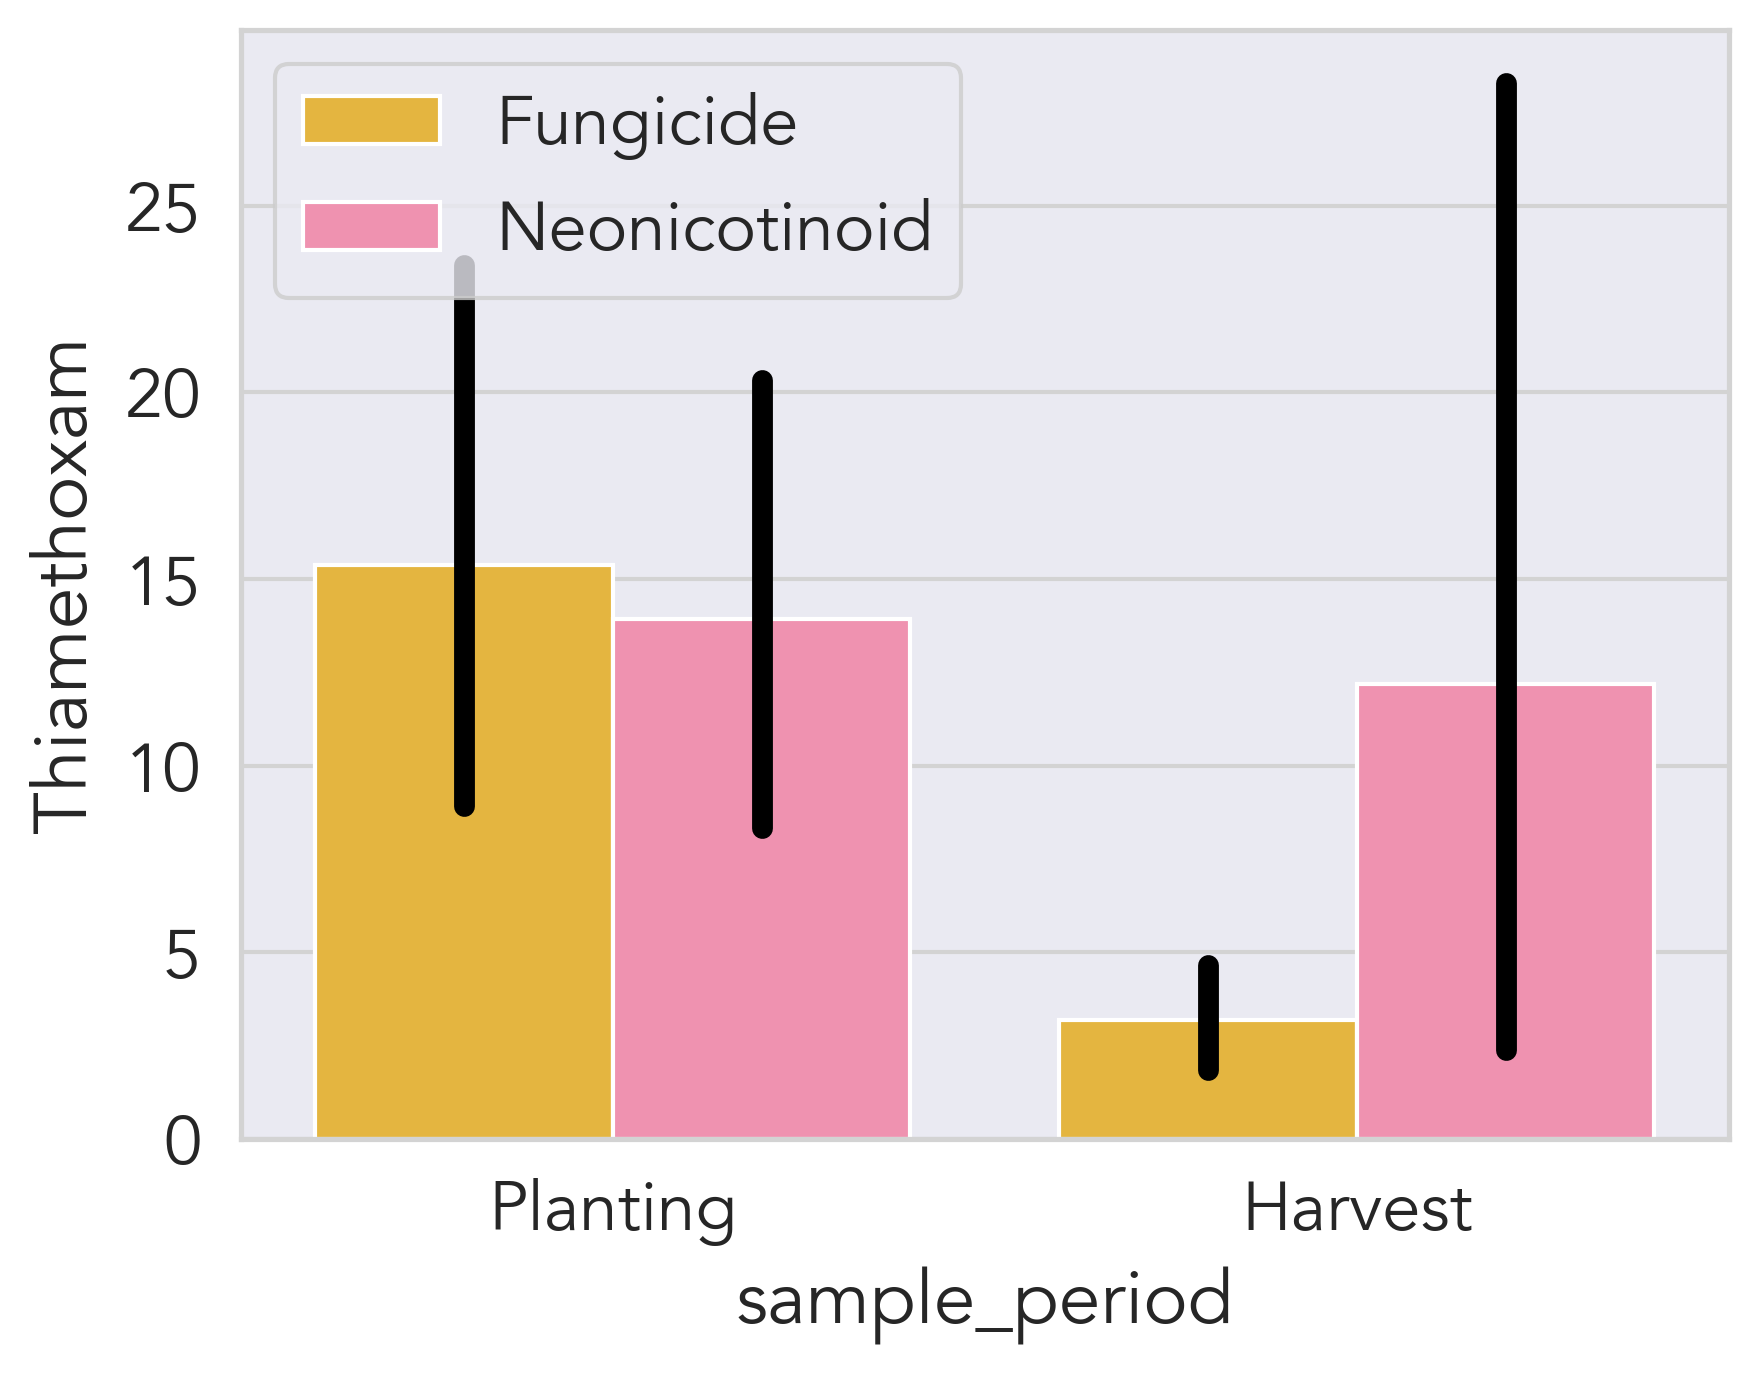

In [12]:
plt.figure()
plt.rcParams.update({"figure.dpi": 300})
sns.set(font="Avenir", font_scale=1.5, rc={'grid.color': 'lightgray', 'axes.edgecolor': 'lightgray', 'legend.frameon':True})

# palette = ['#7e3412', '#d2e1c1']
palette = ['#FFC125', '#FF82AB']
hue_order = ['Fungicide', 'Neonicotinoid']

residue_data['thiamethoxam'] = pd.to_numeric(residue_data['thiamethoxam'], errors='coerce').dropna()

ax = sns.barplot(data = residue_data, x = 'sample_period', y = 'thiamethoxam', hue = 'pesticide_treatment', palette=palette, hue_order=hue_order, err_kws={'linewidth': 5, 'color':'black'})
plt.ylabel('Thiamethoxam')
plt.legend(loc='upper left')
#plt.ylim(0, 1)



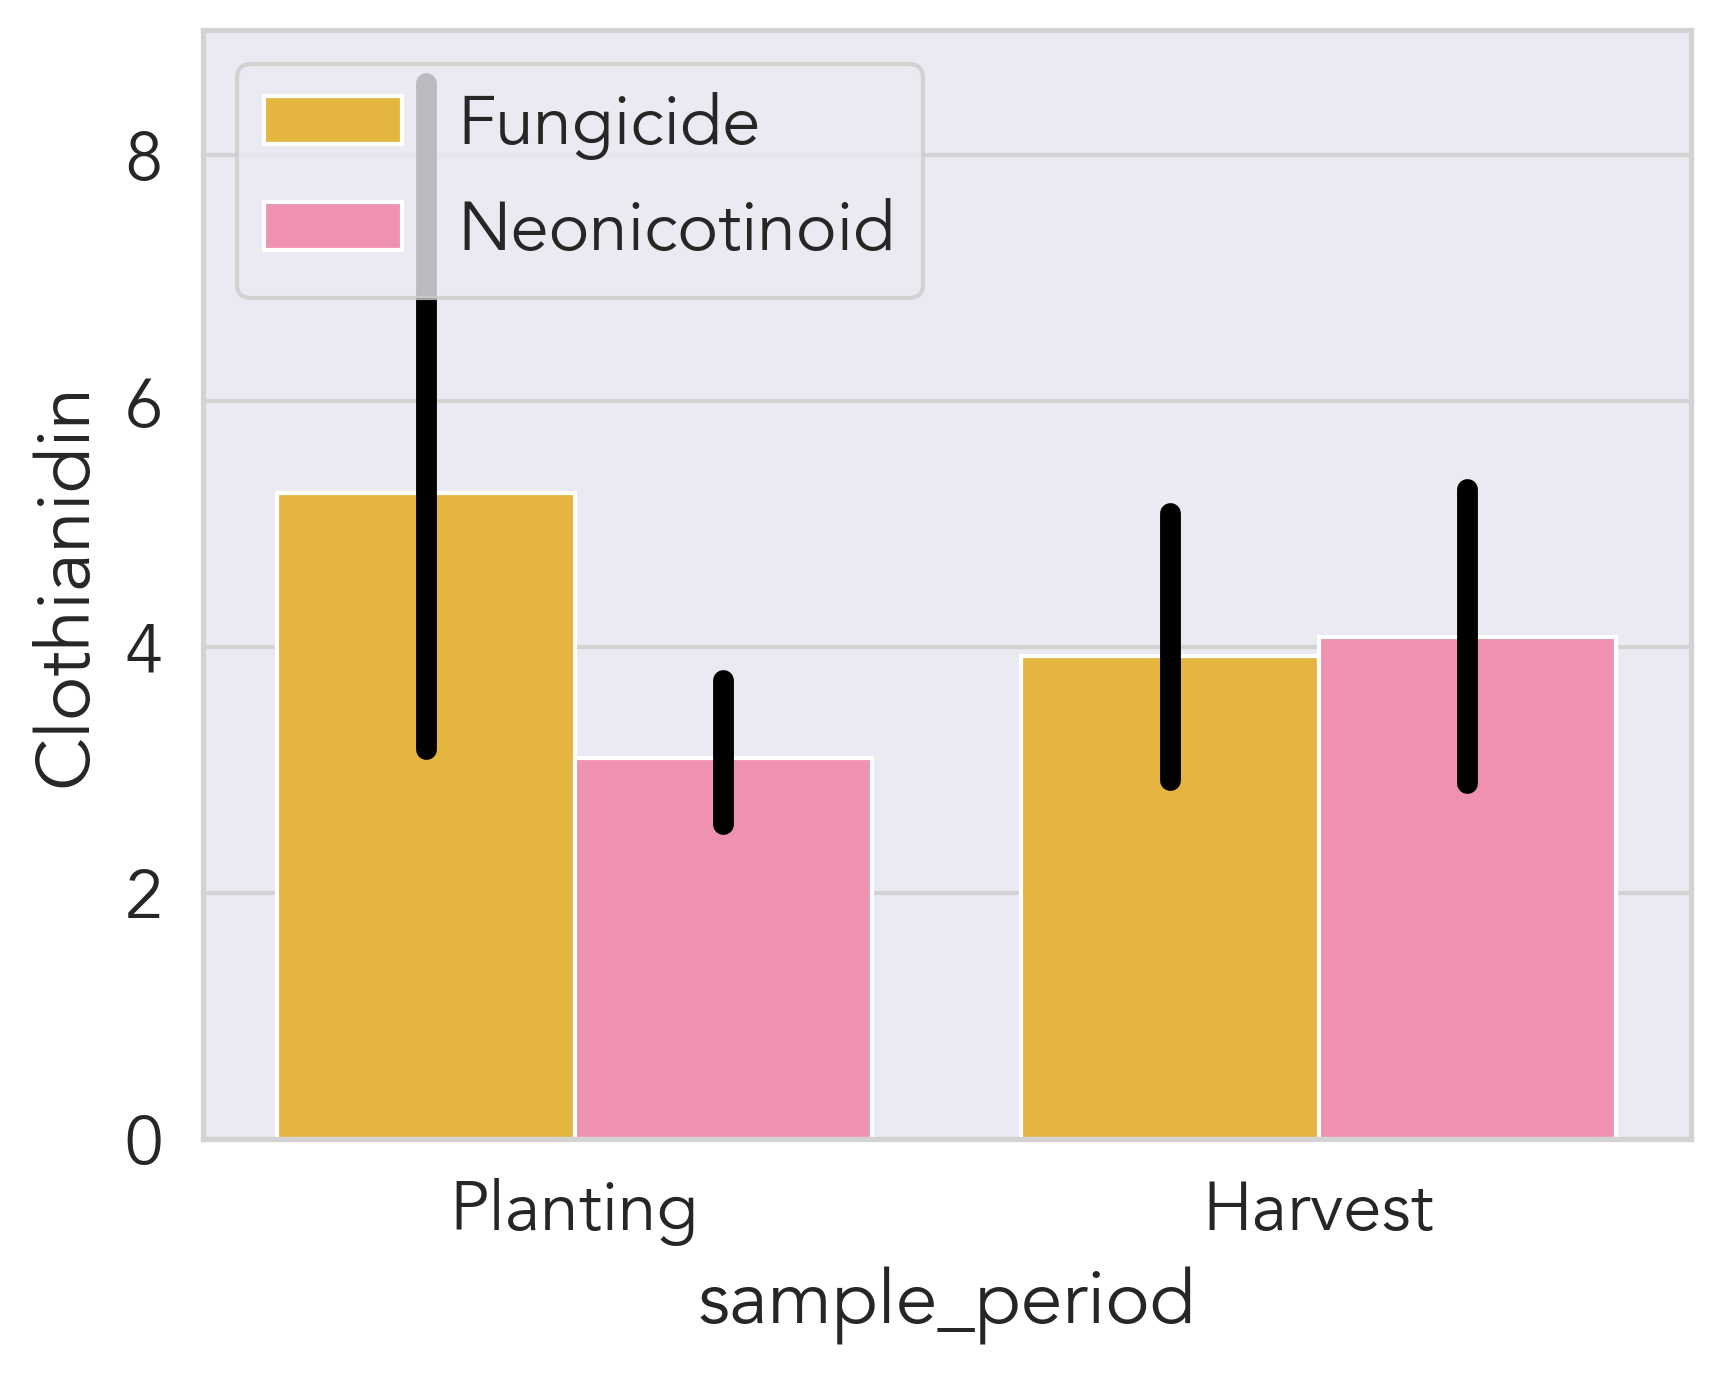

In [14]:
plt.figure()
plt.rcParams.update({"figure.dpi": 300})
sns.set(font="Avenir", font_scale=1.5, rc={'grid.color': 'lightgray', 'axes.edgecolor': 'lightgray', 'legend.frameon':True})

# palette = ['#7e3412', '#d2e1c1']
palette = ['#FFC125', '#FF82AB']
hue_order = ['Fungicide', 'Neonicotinoid']

residue_data['clothianidin'] = pd.to_numeric(residue_data['clothianidin'], errors='coerce').dropna()

ax = sns.barplot(data = residue_data, x = 'sample_period', y = 'clothianidin', hue = 'pesticide_treatment', palette=palette, hue_order=hue_order, err_kws={'linewidth': 5, 'color':'black'})
plt.ylabel('Clothianidin')
plt.legend(loc='upper left')
#plt.ylim(0, 1)

